In [69]:
import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timezone


## Power forecasts ANEMOI

In [70]:
FORECAST_DIR = Path("/mnt/data/weatherloss/WindPower/inference/Huber4")
OBS_PATH = Path("/mnt/data/weatherloss/WindPower/verification/BE_offshore_3H_totalMW.csv")

# Aug 2024 window
START = pd.Timestamp("2024-08-01 00:00:00", tz="UTC")
END   = pd.Timestamp("2024-08-31 23:59:59", tz="UTC")

In [71]:
obs = pd.read_csv(OBS_PATH)
obs["time"] = pd.to_datetime(obs["time"], utc=True)
for c in obs.columns:
    if c.lower().startswith("total") and c.lower().endswith("mw"):
        total_col = c
obs = obs[(obs["time"] >= START) & (obs["time"] <= END)].copy()
obs = obs[["time", total_col]].rename(columns={total_col: "obs_MW"}).reset_index(drop=True)

In [72]:
files = sorted([p for p in FORECAST_DIR.glob("forecast_202408*.nc")])
turbine_cells = [
    (56, 119),  # Belwind / Nobelwind
    (54, 121),  # CPower_NE / Rentel
    (53, 120),  # CPower_SW
    (57, 118),  # Mermaid
    (53, 121),  # Norther
    (56, 118),  # Northwester2
    (55, 120),  # Northwind / Seastar
]

In [73]:
first = xr.open_dataset(files[0])
Ny, Nx = 157, 211
lat2d = first["latitude"].values.reshape(Ny, Nx)
lon2d = first["longitude"].values.reshape(Ny, Nx)

idxs = []
for (y, x) in turbine_cells:
    lat_target = lat2d[y, x]
    lon_target = lon2d[y, x]
    # find the flat index of this (y,x)
    flat_idx = y * Nx + x
    idxs.append(int(flat_idx))

turbine_value_indices = np.array(idxs, dtype=int)

In [74]:
def load_sum_power(path, value_indices):
    ds = xr.open_dataset(path)
    p = ds["power"].isel(values=value_indices).sum(dim="values")

    # make a tidy frame with time + fcst_MW
    out = (
        p.to_series()                  # index = time, name = 'power'
         .rename("fcst_MW")            # rename series
         .reset_index()                # -> columns: ['time','fcst_MW']
    )

    # init time from filename and lead hours
    init = pd.to_datetime(re.search(r"forecast_(\d{14})\.nc", path.name).group(1),
                          format="%Y%m%d%H%M%S", utc=True)
    out["time"] = pd.to_datetime(out["time"], utc=True)
    out["init_time"] = init
    out["lead_hours"] = ((out["time"] - init).dt.total_seconds() / 3600).astype(int)

    # keep 0..24h leads
    return out[(out["lead_hours"] >= 0) & (out["lead_hours"] <= 24)][
        ["time","init_time","lead_hours","fcst_MW"]
    ]


In [75]:
flat_idx_grid = np.arange(Ny * Nx).reshape(Ny, Nx)
turbine_cells = [(56,119),(54,121),(53,120),(57,118),(53,121),(56,118),(55,120)]
turbine_value_indices = np.array([int(flat_idx_grid[y, x]) for (y, x) in turbine_cells])

In [76]:
fcst = pd.concat([load_sum_power(p, turbine_value_indices) for p in files], ignore_index=True)

In [77]:
pairs = fcst.merge(obs, on="time", how="inner")
pairs["err"] = pairs["fcst_MW"] - pairs["obs_MW"]

metrics_ANEMOI = (
    pairs.groupby("lead_hours")
         .agg(count=("err","size"),
              MAE =("err", lambda s: s.abs().mean()),
              RMSE=("err", lambda s: np.sqrt((s**2).mean())),
              Bias=("err","mean"))
         .reset_index()
         .sort_values("lead_hours")
)

metrics_ANEMOI

,lead_hours,count,MAE,RMSE,Bias
0,0,247,629.249663,925.218117,-629.249663
1,3,246,276.317321,396.796976,-73.266786
2,6,245,319.796129,435.634856,-28.879664
3,9,244,375.094654,498.166191,0.983312
4,12,243,407.961120,543.744180,-22.349071
5,15,242,437.584966,578.530387,-51.324741
6,18,241,466.063399,616.349641,-81.181850
7,21,240,483.995127,646.640212,-113.767267
8,24,239,502.730160,671.865495,-151.994716


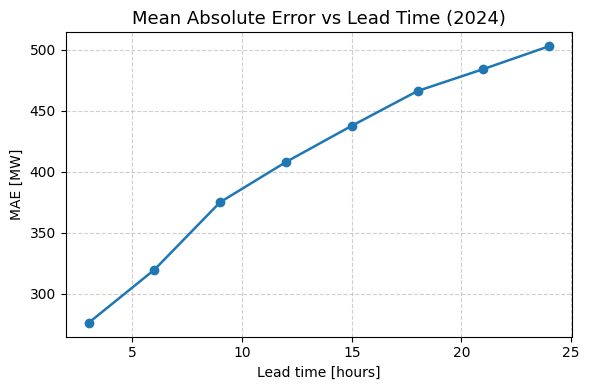

In [78]:
plt.figure(figsize=(6,4))
plt.plot(metrics_ANEMOI["lead_hours"][1:], metrics_ANEMOI["MAE"][1:], marker="o", lw=1.8)
plt.title("Mean Absolute Error vs Lead Time (2024)", fontsize=13)
plt.xlabel("Lead time [hours]")
plt.ylabel("MAE [MW]")
plt.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Very basic power curve

In [79]:
lookup_path = Path("/mnt/data/weatherloss/WindPower/data/BOZ_Turbines/coordinates/farm_to_cell_lookup.csv")
df_lookup = pd.read_csv(lookup_path)

# Identify turbine-type columns
type_cols = [c for c in df_lookup.columns if c.startswith("turbines_")]
assert type_cols, "No turbine-type columns found (expected columns starting with 'turbines_')."

# Aggregate counts per cell, then align to turbine_cells order
idx = pd.MultiIndex.from_tuples(turbine_cells, names=["y", "x"])
counts_per_cell = (
    df_lookup.groupby(["y", "x"])[type_cols]
    .sum()                         # handles multiple farms per cell
    .reindex(idx, fill_value=0)    # enforce order of turbine_cells
)

# Labels and matrix
type_labels = type_cols
counts_matrix = counts_per_cell.to_numpy(dtype="float32")  # shape: (cells, types)



In [80]:
# Define simple piecewise power curves (MW) per turbine type column.
# Adjust cut-in/rated/cut-out or p_rated as needed if you have better specs.
curves = {
    # col_name: (cut_in, rated_at, cut_out, p_rated_MW)
    "turbines_repower_5m126_5mw": (3.5, 12.0, 25.0, 5.0),
    "turbines_repower_62m126_615mw": (3.5, 12.0, 25.0, 6.15),
    "turbines_repower_62m126_615mw_phase3": (3.5, 12.0, 25.0, 6.15),
    "turbines_vestas_v90_3mw": (4.0, 13.0, 25.0, 3.0),
    "turbines_alstom_haliade_150_6mw": (3.5, 11.0, 25.0, 6.0),
    "turbines_vestas_v112_3mw": (3.5, 13.0, 25.0, 3.0),
    "turbines_vestas_v112_33mw": (3.5, 13.0, 25.0, 3.3),
    "turbines_siemens_swt_70_154_735mw": (3.5, 12.0, 25.0, 7.35),
    "turbines_mhi_vestas_v164_84mw": (3.5, 13.0, 25.0, 8.4),
    "turbines_mhi_vestas_v164_95mw": (3.5, 13.0, 25.0, 9.5),
    "turbines_siemens_gamesa_sg_80_167_dd_84mw": (3.5, 12.0, 25.0, 8.4),
}

missing = [c for c in type_cols if c not in curves]
if missing:
    raise ValueError(f"Missing curve params for: {missing}")

def pc_curve(ws, ci, rated_at, co, p_rated):
    return np.where(
        ws < ci, 0.0,
        np.where(
            ws < rated_at,
            (ws - ci) / (rated_at - ci) * p_rated,
            np.where(ws < co, p_rated, 0.0),
        )
    )

In [97]:
files = sorted(Path("/mnt/data/weatherloss/WindPower/inference/Huber4").glob("forecast_202408*.nc"))

def load_powercurve_sum(path, ws_var="ws100"):
    ds = xr.open_dataset(path)
    init_utc = pd.to_datetime(
        re.search(r"forecast_(\d{14})\.nc", path.name).group(1),
        format="%Y%m%d%H%M%S",
        utc=True,
    )
    t = pd.to_datetime(ds["time"].values)          # naive
    t_utc = t.tz_localize("UTC")                   # make it UTC-aware
    lead_hours = ((t_utc - init_utc) / np.timedelta64(1, "h")).astype(int)
    valid_time = t_utc.tz_localize(None)           # back to naive for merging

    ws = ds[ws_var].isel(values=turbine_value_indices)

    total = xr.zeros_like(ws)
    for i, tcol in enumerate(type_labels):
        ci, rated_at, co, p_rated = curves[tcol]
        pc = xr.apply_ufunc(
            pc_curve, ws, ci, rated_at, co, p_rated,
            vectorize=True, dask="parallelized", output_dtypes=[np.float32],
        )
        total = total + pc * counts_matrix[:, i]

    summed = total.sum(dim="values")
    return pd.DataFrame({
        "time": valid_time,
        "init_time": init_utc.tz_localize(None),
        "lead_hours": lead_hours,
        "pc_MW": summed.to_series().values,
    })[(lead_hours >= 0) & (lead_hours <= 24)]

pc_fcst = pd.concat([load_powercurve_sum(p) for p in files], ignore_index=True)



In [98]:
pc_fcst["time"] = pd.to_datetime(pc_fcst["time"]).dt.tz_localize(None)
obs["time"] = pd.to_datetime(obs["time"]).dt.tz_localize(None)

pc_pairs = pc_fcst.merge(obs, on="time", how="inner").dropna(subset=["pc_MW", "obs_MW"])
pc_pairs["err"] = pc_pairs["pc_MW"] - pc_pairs["obs_MW"]

pc_metrics = (
    pc_pairs.groupby("lead_hours")
            .agg(count=("err", "size"),
                 MAE =("err", lambda s: s.abs().mean()),
                 RMSE=("err", lambda s: np.sqrt((s**2).mean())),
                 Bias=("err", "mean"))
            .reset_index()
            .sort_values("lead_hours")
)
pc_metrics

,lead_hours,count,MAE,RMSE,Bias
0,0,247,474.456476,593.793233,455.569547
1,3,246,804.538886,889.820833,784.182488
2,6,245,820.696696,916.342550,777.977945
3,9,244,830.384582,926.705977,759.518045
4,12,243,839.080194,932.981975,738.557162
5,15,242,847.814900,939.920198,719.146790
6,18,241,847.303481,943.405104,698.184290
7,21,240,834.392216,937.098158,675.874055
8,24,239,817.135801,924.126283,645.738572


In [92]:
pc_pairs["err"] = pc_pairs["pc_MW"] - pc_pairs["obs_MW"]

pc_metrics = (
    pc_pairs.groupby("lead_hours")
            .agg(count=("err", "size"),
                 MAE =("err", lambda s: s.abs().mean()),
                 RMSE=("err", lambda s: np.sqrt((s**2).mean())),
                 Bias=("err", "mean"))
            .reset_index()
            .sort_values("lead_hours")
)
pc_metrics

,lead_hours,count,MAE,RMSE,Bias
0,0,247,474.456476,593.793233,455.569547
1,3,246,804.538886,889.820833,784.182488
2,6,245,820.696696,916.342550,777.977945
3,9,244,830.384582,926.705977,759.518045
4,12,243,839.080194,932.981975,738.557162
5,15,242,847.814900,939.920198,719.146790
6,18,241,847.303481,943.405104,698.184290
7,21,240,834.392216,937.098158,675.874055
8,24,239,817.135801,924.126283,645.738572


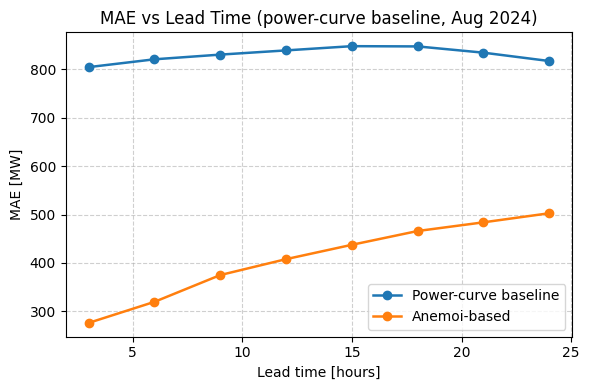

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(pc_metrics["lead_hours"][1:], pc_metrics["MAE"][1:], marker="o", lw=1.8, label="Power-curve baseline")
plt.plot(metrics_ANEMOI["lead_hours"][1:], metrics_ANEMOI["MAE"][1:], marker="o", lw=1.8,label="Anemoi-based")
plt.title("MAE vs Lead Time (power-curve baseline, Aug 2024)")
plt.xlabel("Lead time [hours]")
plt.ylabel("MAE [MW]")
plt.grid(True, ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
p = files[0]
ds = xr.open_dataset(p)
t = pd.to_datetime(ds["time"].values)          # naive datetimes
t_utc = t.tz_localize("UTC")                   # make them UTC-aware
init_utc = pd.to_datetime(
    re.search(r"forecast_(\d{14})\.nc", p.name).group(1),
    format="%Y%m%d%H%M%S",
    utc=True,
)

lead_hours = ((t_utc - init_utc) / np.timedelta64(1, "h")).astype(int)
print("lead_hours head:", lead_hours[:8])


lead_hours head: Index([0, 3, 6, 9, 12, 15, 18, 21], dtype='int64')
